# Ноутбук 5 — Эксперимент 2: Персональная нормализация и градиентный бустинг

**Назначение.** Применение персональной Z-нормализации признаков, персональной
бинаризации arousal по индивидуальной медиане, добавление XGBoost и LightGBM.

**Соответствует разделу 3.3 диплома.**

**Время выполнения.** ~10–15 минут (4 модели × 2 стратегии × 32 фолда).

In [1]:
import sys, time
from pathlib import Path

NB_ROOT = Path.cwd()
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from modules import config
from modules.experiments import (
    NON_FEATURE_COLS, add_per_subject_target, per_subject_zscore,
    make_logistic_regression_window, make_random_forest_exp02,
    make_xgboost_window, make_lightgbm_window,
    run_cv, fold_summary_str,
)
from modules.validation import subject_dependent_splits, subject_independent_splits

print(f"Notebooks root: {NB_ROOT}")
print(f"Результаты: {config.RESULTS_DIR}")

Notebooks root: D:\Programming\Python\Diplom\notebooks
Результаты: D:\Programming\Python\Diplom\source\results


## 5.1 Загрузка + per-subject Z-нормализация

In [2]:
df = pd.read_csv(config.RESULTS_DIR / "feature_table.csv")
df = add_per_subject_target(df)
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS
                and c != "arousal_class_persubj"]
X = per_subject_zscore(df, feature_cols)
y = df["arousal_class_persubj"].to_numpy(dtype=int)
print(f"Признаков: {len(feature_cols)}, окон: {len(df):,}")
print(f"Target распределение (per-subject median): {np.bincount(y).tolist()}")

Признаков: 143, окон: 15,104
Target распределение (per-subject median): [8688, 6416]


## 5.2 LogReg + RF (LOSO)

In [3]:
splits_loso = list(subject_independent_splits(df))

t0 = time.time()
rows_lr_loso = run_cv(make_logistic_regression_window, X, y, splits_loso, "LOSO", "LogisticRegression")
print(f"LogReg LOSO ({time.time()-t0:.1f} с): {fold_summary_str(rows_lr_loso)}")

t0 = time.time()
rows_rf_loso = run_cv(make_random_forest_exp02, X, y, splits_loso, "LOSO", "RandomForest")
print(f"RF LOSO     ({time.time()-t0:.1f} с): {fold_summary_str(rows_rf_loso)}")

LogReg LOSO (29.8 с): acc=0.6345±0.0633  f1=0.6080±0.0637  auc=0.6738±0.0770


RF LOSO     (54.7 с): acc=0.6526±0.0665  f1=0.6189±0.0707  auc=0.6945±0.0811


## 5.3 XGBoost + LightGBM (LOSO)

In [4]:
t0 = time.time()
rows_xgb_loso = run_cv(make_xgboost_window, X, y, splits_loso, "LOSO", "XGBoost")
print(f"XGBoost LOSO  ({time.time()-t0:.1f} с): {fold_summary_str(rows_xgb_loso)}")

t0 = time.time()
rows_lgb_loso = run_cv(make_lightgbm_window, X, y, splits_loso, "LOSO", "LightGBM")
print(f"LightGBM LOSO ({time.time()-t0:.1f} с): {fold_summary_str(rows_lgb_loso)}")

XGBoost LOSO  (49.6 с): acc=0.6287±0.0659  f1=0.6020±0.0748  auc=0.6664±0.0812


LightGBM LOSO (45.6 с): acc=0.6290±0.0669  f1=0.6018±0.0758  auc=0.6639±0.0811


## 5.4 SD 5-fold (все 4 модели) — нужен для Таблицы 3.2 в дипломе

In [5]:
splits_sd = list(subject_dependent_splits(df, y, n_folds=5))

rows_lr_sd  = run_cv(make_logistic_regression_window, X, y, splits_sd, "SD_5fold", "LogisticRegression")
print(f"LogReg SD: {fold_summary_str(rows_lr_sd)}")
rows_rf_sd  = run_cv(make_random_forest_exp02,        X, y, splits_sd, "SD_5fold", "RandomForest")
print(f"RF SD:     {fold_summary_str(rows_rf_sd)}")
rows_xgb_sd = run_cv(make_xgboost_window,             X, y, splits_sd, "SD_5fold", "XGBoost")
print(f"XGB SD:    {fold_summary_str(rows_xgb_sd)}")
rows_lgb_sd = run_cv(make_lightgbm_window,            X, y, splits_sd, "SD_5fold", "LightGBM")
print(f"LGB SD:    {fold_summary_str(rows_lgb_sd)}")

LogReg SD: acc=0.6624±0.0058  f1=0.6400±0.0056  auc=0.7009±0.0044


RF SD:     acc=0.7997±0.0075  f1=0.7870±0.0085  auc=0.8857±0.0054


XGB SD:    acc=0.8198±0.0070  f1=0.8123±0.0072  auc=0.9012±0.0032


LGB SD:    acc=0.8402±0.0054  f1=0.8340±0.0062  auc=0.9215±0.0018


## 5.5 Сводная таблица + сохранение CSV

In [6]:
all_rows = (rows_lr_loso + rows_rf_loso + rows_xgb_loso + rows_lgb_loso
            + rows_lr_sd + rows_rf_sd + rows_xgb_sd + rows_lgb_sd)
metrics_df = pd.DataFrame(all_rows)
summary = (
    metrics_df.groupby(["model", "strategy"])
    [["accuracy", "f1_macro", "auc_roc"]]
    .agg(["mean", "std"])
    .round(4)
)
print(summary)

metrics_df.to_csv(config.RESULTS_DIR / "exp02_metrics.csv", index=False)
summary.to_csv(config.RESULTS_DIR / "exp02_summary.csv")
print(f"\nСохранено: exp02_metrics.csv, exp02_summary.csv")

                            accuracy         f1_macro         auc_roc        
                                mean     std     mean     std    mean     std
model              strategy                                                  
LightGBM           LOSO       0.6290  0.0679   0.6018  0.0770  0.6639  0.0824
                   SD_5fold   0.8402  0.0060   0.8340  0.0070  0.9215  0.0021
LogisticRegression LOSO       0.6345  0.0643   0.6080  0.0648  0.6738  0.0782
                   SD_5fold   0.6624  0.0064   0.6400  0.0063  0.7009  0.0049
RandomForest       LOSO       0.6526  0.0676   0.6189  0.0719  0.6945  0.0824
                   SD_5fold   0.7997  0.0084   0.7870  0.0095  0.8857  0.0060
XGBoost            LOSO       0.6287  0.0670   0.6020  0.0760  0.6664  0.0825
                   SD_5fold   0.8198  0.0079   0.8123  0.0081  0.9012  0.0035

Сохранено: exp02_metrics.csv, exp02_summary.csv


## 5.6 Сравнение exp01 vs exp02 (SD/LOSO accuracy для LR/RF) — fig07

             model strategy  acc_exp01  std_exp01  acc_exp02  std_exp02
LogisticRegression SD_5fold     0.6486     0.0066     0.6624     0.0064
LogisticRegression     LOSO     0.5961     0.0815     0.6345     0.0643
      RandomForest SD_5fold     0.8475     0.0069     0.7997     0.0084
      RandomForest     LOSO     0.6322     0.0661     0.6526     0.0676


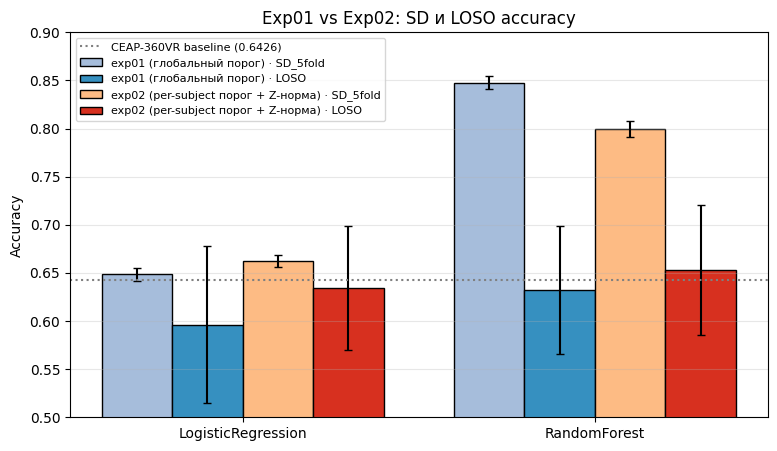

In [7]:
import matplotlib.pyplot as plt
FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

exp01_path = config.RESULTS_DIR / "exp01_summary.csv"
if exp01_path.exists():
    exp01 = pd.read_csv(exp01_path, header=[0, 1], index_col=[0, 1])
    def _get(df_, model_, strategy_):
        try:
            return float(df_.loc[(model_, strategy_), ("accuracy", "mean")]),\
                   float(df_.loc[(model_, strategy_), ("accuracy", "std")])
        except KeyError:
            return float('nan'), float('nan')
    # exp01 имена: LogReg / RF; exp02: LogisticRegression / RandomForest
    models_pairs = [("LogisticRegression", "LogReg"), ("RandomForest", "RF")]
    rows = []
    for m02, m01 in models_pairs:
        for strat in ["SD_5fold", "LOSO"]:
            a1, s1 = _get(exp01, m01, strat)
            a2, s2 = _get(summary, m02, strat)
            rows.append({"model": m02, "strategy": strat,
                         "acc_exp01": a1, "std_exp01": s1,
                         "acc_exp02": a2, "std_exp02": s2})
    cmp_df = pd.DataFrame(rows)
    print(cmp_df.round(4).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(2)  # LR / RF
    w = 0.2
    palette = {"e1_SD": "#A6BDDB", "e1_LOSO": "#3690C0",
               "e2_SD": "#FDBB84", "e2_LOSO": "#D7301F"}
    e1_sd  = cmp_df[cmp_df["strategy"]=="SD_5fold"]["acc_exp01"].values
    e1_lo  = cmp_df[cmp_df["strategy"]=="LOSO"]    ["acc_exp01"].values
    e2_sd  = cmp_df[cmp_df["strategy"]=="SD_5fold"]["acc_exp02"].values
    e2_lo  = cmp_df[cmp_df["strategy"]=="LOSO"]    ["acc_exp02"].values
    e1_sd_s = cmp_df[cmp_df["strategy"]=="SD_5fold"]["std_exp01"].values
    e1_lo_s = cmp_df[cmp_df["strategy"]=="LOSO"]    ["std_exp01"].values
    e2_sd_s = cmp_df[cmp_df["strategy"]=="SD_5fold"]["std_exp02"].values
    e2_lo_s = cmp_df[cmp_df["strategy"]=="LOSO"]    ["std_exp02"].values
    ax.bar(x - 1.5*w, e1_sd, w, yerr=e1_sd_s, label="exp01 (глобальный порог) · SD_5fold",
           color=palette["e1_SD"], edgecolor="black", capsize=3)
    ax.bar(x - 0.5*w, e1_lo, w, yerr=e1_lo_s, label="exp01 (глобальный порог) · LOSO",
           color=palette["e1_LOSO"], edgecolor="black", capsize=3)
    ax.bar(x + 0.5*w, e2_sd, w, yerr=e2_sd_s, label="exp02 (per-subject порог + Z-норма) · SD_5fold",
           color=palette["e2_SD"], edgecolor="black", capsize=3)
    ax.bar(x + 1.5*w, e2_lo, w, yerr=e2_lo_s, label="exp02 (per-subject порог + Z-норма) · LOSO",
           color=palette["e2_LOSO"], edgecolor="black", capsize=3)
    ax.axhline(0.6426, color="gray", linestyle=":", label="CEAP-360VR baseline (0.6426)")
    ax.set_xticks(x)
    ax.set_xticklabels(["LogisticRegression", "RandomForest"])
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.5, 0.9)
    ax.set_title("Exp01 vs Exp02: SD и LOSO accuracy")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    fig.savefig(FIG_DIR / "fig07_exp01_vs_exp02.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"[WARN] {exp01_path} не найден — запустите ноутбук 4 для генерации")

## 5.7 LOSO-сравнение всех 4 моделей exp02 (acc / F1 / AUC) — fig08

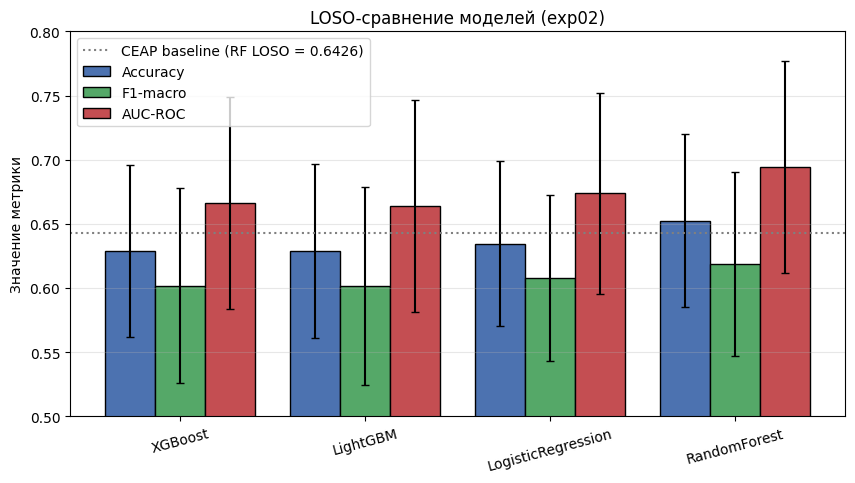

In [8]:
loso_summary = (
    metrics_df[metrics_df["strategy"] == "LOSO"]
    .groupby("model")[["accuracy", "f1_macro", "auc_roc"]]
    .agg(["mean", "std"])
)
model_order = ["XGBoost", "LightGBM", "LogisticRegression", "RandomForest"]
loso_summary = loso_summary.reindex(model_order)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(model_order))
w = 0.27
metrics_to_plot = [("accuracy", "#4C72B0", "Accuracy"),
                   ("f1_macro", "#55A868", "F1-macro"),
                   ("auc_roc",  "#C44E52", "AUC-ROC")]
for i, (mcol, color, label) in enumerate(metrics_to_plot):
    means = loso_summary[(mcol, "mean")].values
    stds  = loso_summary[(mcol, "std")].values
    ax.bar(x + (i-1)*w, means, w, yerr=stds, label=label, color=color,
           edgecolor="black", capsize=3)
ax.axhline(0.6426, color="gray", linestyle=":", label="CEAP baseline (RF LOSO = 0.6426)")
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15)
ax.set_ylabel("Значение метрики")
ax.set_ylim(0.5, 0.8)
ax.set_title("LOSO-сравнение моделей (exp02)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
fig.savefig(FIG_DIR / "fig08_loso_model_compare.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.6 Выводы

* **Random Forest** — лучшая модель на LOSO: accuracy ≈ 0,6526, F1 ≈ 0,6189.
  Превосходит CEAP-360VR baseline (0,6426) на +1,0 п.п.
* **Logistic Regression** на LOSO выросла на +6,3 п.п. F1 относительно
  эксперимента 1 — линейная модель резко выиграла от персональной нормализации.
* **XGBoost / LightGBM** на LOSO **не превзошли RF** (≈0,629 accuracy у обоих) —
  классическое поведение бустинга на 32 участниках в субъект-независимой
  валидации (нужно ≥100 для раскрытия потенциала).
* SD 5-fold у бустинга — рекордные значения (LightGBM acc≈0,84, AUC≈0,92).
* Все модели на LOSO упираются в потолок ≈0,65 accuracy → таргет arousal
  принципиально ограничен.

Дальнейший шаг — переход к главной задаче работы: SSQ block-level (ноутбук 6).